# Revenue Leakage Analysis

## Problem Statement
The business is generating revenue but is experiencing instability in growth. There is a need to identify where revenue is being lost across the customer journey, operations, and seller performance.

## Objective

The objective of this project is to identify and quantify **revenue leakage** in an e-commerce business by analyzing customer behavior, delivery experience, and operational performance.

The analysis focuses on:
- customer retention and repeat purchasing behavior
- experience-driven revenue loss due to delivery delays
- operational leakage from cancellations and seller performance

The goal is to estimate revenue loss, identify major leakage sources, and highlight priority areas for business action.

## Dataset Overview

This analysis uses the Olist e-commerce dataset, which includes customer orders, payments, delivery timelines, reviews, sellers, and products.

Data is assumed to be appropriate for analysis.

## Analysis Structure

The revenue leakage analysis is conducted in four stages:
1. Customer Behavior Analysis
2. Experience-Driven Leakage
3. Operational & Seller-Side Leakage
4. Final Insights & Recommendations

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('olist.db')

In [3]:
tables = pd.read_sql('''SELECT name FROM sqlite_master WHERE type = "table"''', conn)
tables

,name
0,customers
1,location
2,order_items
3,payments
4,reviews
5,orders
6,product
7,seller
8,product_category


In [4]:
for t in tables['name']:
    print(f"\nTable: {t}\n")
    df = pd.read_sql(f'''SELECT * FROM {t} LIMIT 1;''', conn)
    print(df.columns)
    print("-"* 50)


Table: customers

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
--------------------------------------------------

Table: location

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
--------------------------------------------------

Table: order_items

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
--------------------------------------------------

Table: payments

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
--------------------------------------------------

Table: reviews

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answe

In [5]:
for table in tables['name']:
    print(f"\nTable : {table}")
    display(pd.read_sql(f'''SELECT * FROM {table} LIMIT 5;''', conn))
    print("-"*50)


Table : customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


--------------------------------------------------

Table : location


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


--------------------------------------------------

Table : order_items


...

--------------------------------------------------

Table : seller


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


--------------------------------------------------

Table : product_category


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


--------------------------------------------------


## Leakage Analysis

### 01: Customer Behavior
Understand how customer purchase behavior causes revenue leakage, and quantify how big that leakage is in terms of:
- number of customers
- revenue involved

In [6]:
# One-time vs Repeat Customers
pd.read_sql(''' SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
                FROM orders o JOIN customers c
                ON o.customer_id = c.customer_id
                WHERE o.order_status = "delivered"
                GROUP BY 1;
                ''', conn)

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,1
93354,fffea47cd6d3cc0a88bd621562a9d061,1
93355,ffff371b4d645b6ecea244b27531430a,1
93356,ffff5962728ec6157033ef9805bacc48,1


In [7]:
# Customer Classification into One-time and Repeat
query = '''
WITH customer_orders AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT CASE WHEN order_count = 1 THEN 'One-time' 
            ELSE 'Repeat' END AS customer_type,
       COUNT(*) AS customer_count
FROM customer_orders
GROUP BY customer_type;'''

order_freq = pd.read_sql(query, conn)
order_freq

,customer_type,customer_count
0,One-time,90557
1,Repeat,2801


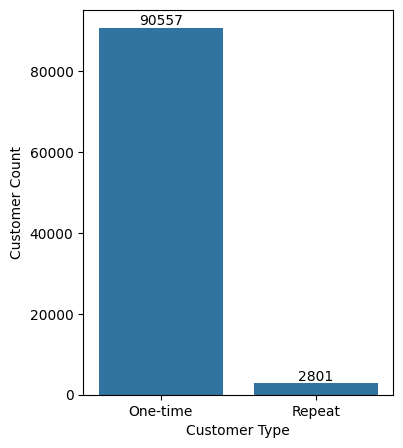

In [8]:
plt.figure(figsize = (4,5))
ax = sns.barplot(x = "customer_type", y = "customer_count", data = order_freq)
ax.bar_label(ax.containers[0])

plt.xlabel("Customer Type")
plt.ylabel("Customer Count")
plt.show()

In [9]:
((order_freq['customer_count'] / order_freq['customer_count'].sum()) * 100).round(2)

0    97.0
1     3.0
Name: customer_count, dtype: float64

In [10]:
# Revenue by Customer-Type
query = '''
WITH customer_orders AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id 
    ),

customer_revenue AS (
    SELECT c.customer_unique_id, SUM(p.payment_value) AS revenue
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p 
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    )
    
SELECT CASE WHEN co.order_count = 1 THEN 'One-time'
            ELSE 'Repeat' END AS customer_type,
       SUM(cr.revenue) AS total_revenue
FROM customer_orders co JOIN customer_revenue cr
ON co.customer_unique_id = cr.customer_unique_id
GROUP BY customer_type;
'''
revenue_per_type = pd.read_sql(query, conn)
revenue_per_type

,customer_type,total_revenue
0,One-time,14558104.56
1,Repeat,864357.21


In [11]:
revenue_per_type['revenue_perc'] = ((revenue_per_type['total_revenue'] / revenue_per_type['total_revenue'].sum())* 100).round(2)
revenue_per_type['revenue_perc']

0    94.4
1     5.6
Name: revenue_perc, dtype: float64

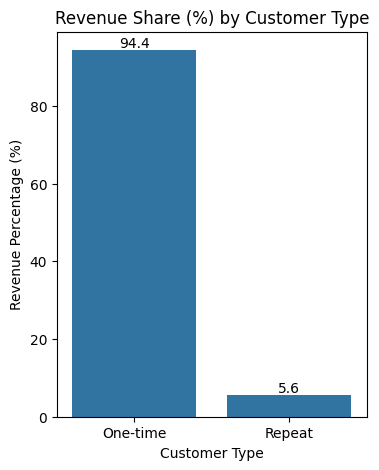

In [12]:
plt.figure(figsize = (4,5))
ax = sns.barplot(data = revenue_per_type, x = 'customer_type', y = 'revenue_perc')
ax.bar_label(ax.containers[0])
plt.xlabel("Customer Type")
plt.ylabel("Revenue Percentage (%)")
plt.title("Revenue Share (%) by Customer Type")
plt.show()

In [13]:
# Average Revenue per Customer (ARPC)
query = '''
WITH customer_orders AS (
    SELECT  c.customer_unique_id, 
            COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

customer_revenue AS (
    SELECT  c.customer_unique_id, 
            SUM(p.payment_value) AS revenue
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p 
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    )

SELECT CASE WHEN co.order_count = 1 THEN 'One-time' 
            ELSE 'Repeat' END AS customer_type,
       COUNT(*) AS customer_count,
       SUM(cr.revenue) AS total_revenue
FROM customer_orders co JOIN customer_revenue cr
ON co.customer_unique_id = cr.customer_unique_id
GROUP BY customer_type;
'''

revenue_customer = pd.read_sql(query, conn)
revenue_customer

,customer_type,customer_count,total_revenue
0,One-time,90556,14558104.56
1,Repeat,2801,864357.21


In [14]:
revenue_customer['avg_revenue'] = (revenue_customer['total_revenue'] / revenue_customer['customer_count']).round(2)
revenue_customer

,customer_type,customer_count,total_revenue,avg_revenue
0,One-time,90556,14558104.56,160.76
1,Repeat,2801,864357.21,308.59


### **Insights:** </br>
- `97%` of customers who are one-time buyers </br>
- `94.4%` of revenue coming from one-time buyers </br>
- ARPC (Average Revenue per Customer) of "repeat" is nearly **2X higher** than for "one-time" customers </br>

Clear evidence of **REVENUE LEAKAGE** due to poor retention

### 02: Experience-Driven Leakage
We will check:
- How many customers face bad experience (`late delivery` OR `low review`)
- How much revenue is associated with them

In [15]:
# Delivery delay identification
query = '''SELECT SUM(CASE WHEN order_estimated_delivery_date < order_delivered_customer_date THEN 1 ELSE 0 END) AS late_delivery
           FROM orders
           WHERE order_status = "delivered";
           '''
pd.read_sql(query, conn)

,late_delivery
0,7826


In [16]:
# Customer impact of delivery delays
query = '''
SELECT COUNT(DISTINCT c.customer_unique_id) AS total_customers
FROM customers c JOIN orders o
ON c.customer_id = o.customer_id
WHERE o.order_status = "delivered" 
AND o.order_delivered_customer_date > o.order_estimated_delivery_date;
'''
# (customers experienced at least one late delivery)
pd.read_sql(query, conn)

,total_customers
0,7771


In [17]:
# Revenue associated with delayed orders
query = '''
SELECT SUM(p.payment_value) AS revenue_at_risk
FROM payments p JOIN orders o
ON p.order_id = o.order_id
WHERE o.order_status = "delivered" 
AND o.order_delivered_customer_date > o.order_estimated_delivery_date;
'''
pd.read_sql(query, conn)

,revenue_at_risk
0,1351646.79


In [18]:
# reviews vs delivery experience
query = '''
SELECT AVG(CASE WHEN (o.order_delivered_customer_date > o.order_estimated_delivery_date) THEN r.review_score END) AS avg_late_score,
       AVG(CASE WHEN (o.order_delivered_customer_date <= o.order_estimated_delivery_date) THEN r.review_score END) AS avg_on_time_score
FROM reviews r JOIN orders o
ON r.order_id = o.order_id
WHERE o.order_status = "delivered";
''' # AVG() ignores NULL values.
pd.read_sql(query, conn)

,avg_late_score,avg_on_time_score
0,2.566494,4.293718


In [19]:
# Experience & Customer return behaviour
query = '''
WITH bad_exp_customers AS (
    SELECT DISTINCT c.customer_unique_id AS id
    FROM customers c 
    JOIN orders o
    ON c.customer_id = o.customer_id
    JOIN reviews r 
    ON r.order_id = o.order_id
    WHERE (o.order_status = "delivered" AND (o.order_delivered_customer_date > o.order_estimated_delivery_date) 
        AND r.review_score <= 2)
), 
customers_order_count AS (
    SELECT b.id, COUNT(o.order_id) AS total_orders
    FROM bad_exp_customers b JOIN customers c
    ON b.id = c.customer_unique_id
    JOIN orders o
    ON o.customer_id = c.customer_id
    GROUP BY b.id
)

SELECT SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) AS one_time, 
       SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat
FROM customers_order_count;
'''

pd.read_sql(query, conn)

,one_time,repeat
0,3933,188


### **Insights:** </br>
- `7826` orders faced late-delivery. </br>
- `7771` customers faced late-delivery problem. </br>
- `1.35 M` revenue-at-risk due to late-delivery (*bad customer experience*). </br>
- Avg. rating by customers for late-delivery : `2.57` while for on-time : `4.3`
- `188` customers re-ordered even after bad experience while `3933` never ordered again.

Clear evidence of **REVENUE LEAKAGE** due bad experience.

### 03: Operational  & Seller-Side Leakage
we will check where revenue is lost because the business or sellers failed to execute properly. </br>
This will include:
- orders that never got completed
- sellers (operational) causing delays or cancellations
- revenue that should have happened but didn’t


In [20]:
# Order Cancellation Leakage

query = '''SELECT SUM(p.payment_value) AS total_revenue
           FROM orders o JOIN payments p
           ON o.order_id = p.order_id
           WHERE o.order_status = "canceled";
'''
pd.read_sql(query, conn)

,total_revenue
0,143255.6


In [21]:
# Seller-related delivery delays
query = '''
SELECT o2.seller_id, COUNT(o.order_id) AS delayed_orders
FROM order_items o2 JOIN orders o
ON o2.order_id = o.order_id
WHERE o.order_status = "delivered" 
AND o.order_delivered_customer_date > o.order_estimated_delivery_date
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10;
'''
pd.read_sql(query, conn)

,seller_id,delayed_orders
0,4a3ca9315b744ce9f8e9374361493884,214
1,1f50f920176fa81dab994f9023523100,182
2,4869f7a5dfa277a7dca6462dcf3b52b2,133
3,1025f0e2d44d7041d6cf58b6550e0bfa,131
4,7c67e1448b00f6e969d365cea6b010ab,130
5,6560211a19b47992c3666cc44a7e94c0,124
6,ea8482cd71df3c1969d7b9473ff13abc,123
7,955fee9216a65b617aa5c0531780ce60,119
8,da8622b14eb17ae2831f4ac5b9dab84a,113
9,cc419e0650a3c5ba77189a1882b7556a,103


In [22]:
# Revenue Impacted by Poor Seller Performance
query = '''
WITH seller_perfm AS (
    SELECT
        oi.seller_id,
        COUNT(DISTINCT o.order_id) AS total_orders,
        COUNT(DISTINCT CASE
            WHEN o.order_status = 'delivered'
             AND o.order_delivered_customer_date > o.order_estimated_delivery_date
            THEN o.order_id
        END) AS late_orders
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    GROUP BY oi.seller_id
),
bad_perfm_seller AS (
    SELECT seller_id
    FROM seller_perfm
    WHERE late_orders >= 0.25 * total_orders
      AND late_orders >= 15
),
late_orders AS (
    SELECT DISTINCT
        oi.order_id
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN bad_perfm_seller b
        ON oi.seller_id = b.seller_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date > o.order_estimated_delivery_date
)
SELECT
    SUM(p.payment_value) AS total_revenue_at_risk
FROM late_orders lo
JOIN payments p
    ON lo.order_id = p.order_id;
'''
# assumed the threshold of bad performance as 25% of total_orders
# & minimum late deliveries should atleast 15
pd.read_sql(query, conn)

,total_revenue_at_risk
0,9108.42


In [23]:
# Seller Concentration Risk
query = '''
WITH seller_revenue AS ( 
            SELECT oi.seller_id, SUM(p.payment_value) AS seller_revenue
            FROM (SELECT DISTINCT order_id, seller_id
                  FROM order_items) oi JOIN payments p
            ON p.order_id = oi.order_id
            GROUP BY 1),
            
    top_seller AS (
            SELECT seller_id, seller_revenue
            FROM seller_revenue
            ORDER BY 2 DESC
            LIMIT 10
    )
    
SELECT ROUND((SUM(seller_revenue) / (SELECT SUM(payment_value) FROM payments))*100 , 3)AS top_10_sellers_contri_perc
FROM top_seller;
''' 
# TOP 10 sellers are assumed as top_sellers
pd.read_sql(query, conn)

,top_10_sellers_contri_perc
0,12.901


### **Insights:** 

- `₹143k`lost due to canceled orders
- `₹9,108` revenue linked to sellers with frequent late deliveries
- `Top 10` sellers contribute `12.9%` of total revenue
- `4–5` sellers identified with consistently poor performance

Clear evidence that primary **REVENUE LEAKAGE** is due to order cancellations, with operational delays being secondary.

## Key Findings
- Customer retention is the largest source of revenue leakage.
- Delivery delays directly reduce customer satisfaction and repeat purchases.
- Order cancellations result in direct and immediate revenue loss.
- Seller concentration risk is low, indicating diversified revenue sources.

## Recommendations
- Prioritize customer retention strategies for high-value repeat customers.
- Improve delivery reliability to reduce experience-driven churn.
- Investigate and reduce root causes of order cancellations.
- Monitor underperforming sellers without over-relying on top sellers.

## Conclusion
The analysis indicates that revenue leakage is driven mainly by operational issues, not by seller concentration or customer demand. Most revenue loss comes from order cancellations, while delivery delays are limited to a small number of sellers and do not pose a major risk. 

Overall, improving operational execution offers the clearest opportunity to stabilize and sustain revenue growth.